# DEAI-opdracht: Lineaire Regressie op Ames Housing

Deze notebook behandelt de ontwikkeling van een lineair regressiemodel voor het voorspellen van de huizenprijs (**SalePrice**). De uitwerking omvat een volledige machine learning-pipeline, van data-ingestie tot modelevaluatie.

### ️Projectopzet

* **Feature Selectie:** Als onafhankelijke variabelen gebruiken we de numerieke features *Overall Qual* (bouwkwaliteit) en *Gr Liv Area* (woonoppervlakte), evenals de categorische feature *Neighborhood* (buurt).
* **Data Preprocessing:** De categorische feature wordt getransformeerd middels *one-hot encoding*. Vervolgens wordt de dataset opgesplitst via een *train-test split* om robuuste validatie van het model mogelijk te maken.
* **Onderzoeksdoel:** Het trainen van het regressiemodel en het evalueren van de predictieve prestaties door verschillende experimentele configuraties kwantitatief te vergelijken.

In [151]:
# Verberg waarschuwingen voor een schonere output
import warnings
warnings.filterwarnings("ignore")

# Dataverwerking en visualisatie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn: preprocessing en pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Scikit-learn: model en evaluatiemetrieken
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Overige
import inspect

### 1. Data-ingestie en Initiële Verkenning

In deze stap laden we de ruwe Ames Housing-dataset en de bijbehorende metadata (de *Data Dictionary*) in het geheugen als Pandas DataFrames. Vervolgens verifiëren we de dimensionaliteit (het aantal rijen en kolommen) en inspecteren we de eerste observaties om de datastructuur te valideren.

In [152]:
# Definieer het pad naar het Excel-bestand
excel_path = "AmesHousing.xlsx"

# Inladen van de dataset en de metadata
df = pd.read_excel(excel_path, sheet_name="AmesHousing")
data_dictionary = pd.read_excel(excel_path, sheet_name="Data Dictionary")

# Controleer de dimensionaliteit (rijen, kolommen)
print(f"Dimensionaliteit van de dataset: {df.shape}")

# Toon de eerste 5 observaties voor een structurele check
display(df.head())

Dimensionaliteit van de dataset: (2930, 12)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


### 2. Metadata en Feature-overzicht Inspecteren

Om gerichte keuzes te kunnen maken tijdens de *feature selectie*, bestuderen we eerst de metadata (de *Data Dictionary*). Dit geeft ons inzicht in de betekenis en het type van elke variabele. Vervolgens genereren we een complete lijst van alle aanwezige kolommen in de dataset.

In [153]:
# Toon de beschrijving van de variabelen (metadata)
display(data_dictionary)

# Print een overzichtelijke lijst van alle beschikbare features (kolommen)
print("Beschikbare features in de dataset:")
print(df.columns.tolist())

,Variabele,Betekenis
0,ID,"Uniek nummer per huis, te vergelijken met een ..."
1,SalePrice,Verkoopprijs van het huis (in dollars: USD)
2,Garage,Geeft weer of het huis wel/geen garage bevat
3,Overall Qual,Algemene kwaliteit van materialen en afwerking...
4,Gr Liv Area,Woonoppervlak boven de grond (square feet)
5,Total Bsmt SF,Totale oppervlakte van de kelder
6,Lot Area,Grootte van het perceel (square feet)
7,Year Built,Bouwjaar van het huis
8,Full Bath,Aantal volledige badkamers
9,Bedroom AbvGr,Aantal slaapkamers boven de grond


Beschikbare features in de dataset:
['ID', 'SalePrice', 'Garage', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr', 'Neighborhood', 'House Style']


### 3. Definitie van Target en Feature Selectie

De afhankelijke variabele (target) voor ons regressiemodel is de **SalePrice**. Gebaseerd op domeinkennis is de hypothese dat de volgende drie onafhankelijke variabelen (features) de hoogste predictieve waarde hebben:

1. **Overall Qual** (Numeriek): De algehele kwaliteit van constructie en afwerking.
2. **Gr Liv Area** (Numeriek): De totale bovengrondse woonoppervlakte.
3. **Neighborhood** (Categorisch): De geografische locatie (wijk), wat een sterke indicator is voor de vastgoedwaarde.

In [154]:
# Definieer de afhankelijke variabele (target)
target = "SalePrice"

# Definieer de onafhankelijke variabelen (features)
initial_features = ["Overall Qual", "Gr Liv Area", "Neighborhood"]

# Specificeer de categorische features voor latere preprocessing (one-hot encoding)
initial_categorical = ["Neighborhood"]

# Controle-output
print(f"Target variabele: {target}")
print(f"Geselecteerde features: {initial_features}")
print(f"Categorische features: {initial_categorical}")

Target variabele: SalePrice
Geselecteerde features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood']
Categorische features: ['Neighborhood']


### 4. Demonstratie van One-Hot Encoding

Om categorische variabelen (zoals *Neighborhood*) geschikt te maken voor wiskundige berekeningen binnen het regressiemodel, moeten deze numeriek worden gerepresenteerd via *one-hot encoding*.

Hieronder demonstreren we het effect van deze transformatie expliciet. **Let op:** In de uiteindelijke modelarchitectuur integreren we deze stap in een `Scikit-Learn Pipeline`. Dit best practice-principe garandeert dat de encoding uitsluitend op de trainingsdata wordt gefit, wat *data leakage* (het weglekken van informatie uit de testset) voorkomt.

In [155]:
# Creëer een preview van de getransformeerde dataset met Pandas get_dummies
encoded_preview = pd.get_dummies(df[initial_features], columns=initial_categorical, dtype=int)

# Vergelijk de dimensionaliteit (aantal features) voor en na de transformatie
print(f"Aantal features vóór encoding: {len(initial_features)}")
print(f"Aantal features ná encoding: {encoded_preview.shape[1]}")

# Inspecteer de resulterende binaire matrix (dummy variabelen)
display(encoded_preview.head())

Aantal features vóór encoding: 3
Aantal features ná encoding: 30


,Overall Qual,Gr Liv Area,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,6,1656,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,896,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,1329,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,7,2110,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1629,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 5. Data Partitioning (Train-Test Split)

Voordat we het regressiemodel kunnen trainen, moeten we de dataset opsplitsen. Dit proces verloopt in twee stappen:
1. **Feature-Target splitsing:** Het scheiden van de voorspellende kenmerken (de onafhankelijke feature matrix, $X$) en de te voorspellen waarde (de afhankelijke target vector, $y$).
2. **Train-Test splitsing:** Het verdelen van de data in een trainingsset (om het model te fitten) en een testset (voor onafhankelijke validatie). We hanteren een hold-out testset van 15%.

Deze bewerkingen resulteren in vier afzonderlijke componenten: `X_train`, `X_test`, `y_train`, en `y_test`.

In [156]:
# Definieer de feature matrix (X) en target vector (y)
X = df[initial_features].copy()
y = df[target].copy()

# Splits de data in een train- en testset (85% train, 15% test)
# De random_state garandeert reproduceerbaarheid van dit experiment
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Verifieer de dimensies van de resulterende partities
print(f"Dimensies X_train: {X_train.shape}")
print(f"Dimensies X_test : {X_test.shape}")
print(f"Dimensies y_train: {y_train.shape}")
print(f"Dimensies y_test : {y_test.shape}")

Dimensies X_train: (2490, 3)
Dimensies X_test : (440, 3)
Dimensies y_train: (2490,)
Dimensies y_test : (440,)


### 6. Inspectie van Hyperparameters (`SGDRegressor`)

Conform de opdracht analyseren we de beschikbare hyperparameters van het algoritme. In deze pipeline implementeren we de **`SGDRegressor`** (Stochastic Gradient Descent). Dit algoritme geniet de voorkeur boven een standaard OLS-regressiemodel, omdat het expliciete controle biedt over het optimalisatieproces via diverse hyperparameters:

* **`max_iter`**: Het maximale aantal iteraties over de trainingsdata (vergelijkbaar met *epochs* in neurale netwerken).
* **`eta0`**: De initiële *learning rate* (stapgrootte van de optimalisatie).
* **`learning_rate`**: De strategie (schedule) voor het dynamisch aanpassen van de leersnelheid tijdens de training.
* **`penalty`**: De regularisatieterm (zoals L1 of L2) om de complexiteit van het model te bestraffen en *overfitting* te voorkomen.

Voor een volledige beschrijving kan de `help()`-functie worden aangeroepen. Hieronder gebruiken we de `inspect`-module om direct de actuele modelparameters en hun standaardwaarden op te halen.

In [157]:
# Gebruik help(SGDRegressor) voor de volledige documentatie (hier als commentaar om de notebook-output compact te houden)
# help(SGDRegressor)

# Inspecteer de default instellingen (signatuur) van het model via de inspect-module
print("Model Signatuur en standaard hyperparameters van SGDRegressor:\n")
print(inspect.signature(SGDRegressor))

Model Signatuur en standaard hyperparameters van SGDRegressor:

(loss='squared_error', *, penalty='l2', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001, shuffle=True, verbose=0, epsilon=0.1, random_state=None, learning_rate='invscaling', eta0=0.01, power_t=0.25, early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, warm_start=False, average=False)


### 7. Constructie van de Machine Learning Pipeline

Om experimenten efficiënt, reproduceerbaar en foutloos (zonder *data leakage*) uit te voeren, abstraheren we het volledige proces naar één modulaire functie: `train_and_evaluate`.

Deze end-to-end functie integreert de volgende componenten:
* **Preprocessing via `ColumnTransformer`:** Numerieke features worden voorzien van missende waarden (mediaan) en gestandaardiseerd (`StandardScaler`). Dit laatste is cruciaal, aangezien de *Stochastic Gradient Descent* optimizer zeer gevoelig is voor de schaal van de data. Categorische variabelen worden aangevuld (modus) en getransformeerd via `OneHotEncoder`.
* **Modellering:** De preprocessing-stappen en de `SGDRegressor` worden gekoppeld in een `Scikit-Learn Pipeline`.
* **Evaluatie:** Na het fitten van het model worden standaard regressiemetrieken berekend, waaronder de Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE) en de determinatiecoëfficiënt ($R^2$).

In [158]:
def train_and_evaluate(features, categorical_features, max_iter=1000, eta0=0.01,
                       learning_rate="constant", penalty="l2", alpha=0.0001,
                       random_state=42):

    # 1. Dynamische data splitsing
    X = df[features].copy()
    y = df[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, random_state=random_state
    )

    numeric_features = [col for col in features if col not in categorical_features]

    # 2. Preprocessing configuratie (ColumnTransformer)
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()) # Cruciaal voor snelle/stabiele convergentie van SGD
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features)
        ]
    )

    # 3. Model initialiseren met gekozen hyperparameters
    model = SGDRegressor(
        max_iter=max_iter,
        eta0=eta0,
        learning_rate=learning_rate,
        penalty=penalty,
        alpha=alpha,
        random_state=random_state
    )

    # 4. End-to-end pipeline construeren
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # 5. Pipeline fitten op de trainset en predicties genereren op de testset
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    # 6. Evaluatiemetrieken berekenen
    mse = mean_squared_error(y_test, predictions)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # 7. Resultaten retourneren als dictionary voor experimentvergelijking
    return {
        "features": features,
        "categorical_features": categorical_features,
        "max_iter": max_iter,
        "eta0": eta0,
        "learning_rate": learning_rate,
        "penalty": penalty,
        "alpha": alpha,
        "X_train_shape": X_train.shape,
        "X_test_shape": X_test.shape,
        "y_train_shape": y_train.shape,
        "y_test_shape": y_test.shape,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "pipeline": pipeline,
        "y_test": y_test,
        "predictions": predictions
    }

### 8. Nulmeting (Baseline Model) Executie

In deze stap voeren we het eerste experiment uit—de nulmeting of *baseline*—met behulp van onze geparametriseerde pipeline-functie. Hiervoor hanteren we de initiële hypothese met drie features (*Overall Qual*, *Gr Liv Area*, *Neighborhood*) en de standaard hyperparameter-configuratie.

De verkregen evaluatiemetrieken (MSE, RMSE, MAE en $R^2$) worden gestructureerd weergegeven in een DataFrame. Deze prestatie-indicatoren fungeren als kwantitatief referentiekader (benchmark) om de toegevoegde waarde van toekomstige modeliteraties—zoals feature engineering of hyperparameter tuning—objectief te kunnen toetsen.

In [159]:
# 1. Executie van het baseline model met de initiële features
initial_run = train_and_evaluate(
    features=["Overall Qual", "Gr Liv Area", "Neighborhood"],
    categorical_features=["Neighborhood"],
    max_iter=1000,
    eta0=0.01,
    learning_rate="constant",
    penalty="l2",
    alpha=0.0001
)

# 2. Extractie en afronding van de evaluatiemetrieken voor rapportagedoeleinden
initial_metrics = pd.DataFrame([{
    "MSE": initial_run["MSE"],
    "RMSE": initial_run["RMSE"],
    "MAE": initial_run["MAE"],
    "R2": initial_run["R2"]
}]).round(4)

# 3. Validatie van de dimensies van de afgesplitste data
print("Dimensies van de data partities:")
print(f"X_train: {initial_run['X_train_shape']}")
print(f"X_test : {initial_run['X_test_shape']}")
print(f"y_train: {initial_run['y_train_shape']}")
print(f"y_test : {initial_run['y_test_shape']}\n")

# 4. Presentatie van de prestatiemetrieken
print("Evaluatiemetrieken Baseline Model:")
display(initial_metrics)

Dimensies van de data partities:
X_train: (2490, 3)
X_test : (440, 3)
y_train: (2490,)
y_test : (440,)

Evaluatiemetrieken Baseline Model:


,MSE,RMSE,MAE,R2
0,1.499674e+09,38725.6208,25014.787,0.8048


### 9. Experimentele Validatie en Hyperparameter Tuning

Om de voorspellende kracht van het model te optimaliseren ten opzichte van de *baseline*, voeren we een systematische reeks experimenten uit.

**Onderzoeksstrategie:**
1. **Feature Uitbreiding:** Geleidelijke toevoeging van extra onafhankelijke variabelen (zowel numeriek als categorisch) om hun incrementele waarde te toetsen.
2. **Observatie van Modeldegradatie:** Bij het includeren van alle 10 features met een constante *learning rate* verwachten we suboptimale convergentie (een afname in prestaties).
3. **Hyperparameter Tuning:** Ter compensatie en optimalisatie experimenteren we met de parameters van de SGD-optimizer:
   * Reductie van de initiële leersnelheid (`eta0`).
   * Implementatie van een dynamische leersnelheid (`learning_rate="adaptive"`).
   * Variatie in het aantal trainingsiteraties (`max_iter` oftewel *epochs*).

In [160]:
# 1. Definitie van de experimentele configuraties
experiment_configs = [
    {
        "run": "Initieel", "reden": "Startmodel met 3 verwachte topfeatures",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood"],
        "categorical": ["Neighborhood"],
        "max_iter": 1000, "eta0": 0.01, "learning_rate": "constant", "penalty": "l2", "alpha": 0.0001
    },
    {
        "run": "Exp1", "reden": "House Style toegevoegd als extra categorische feature",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style"],
        "categorical": ["Neighborhood", "House Style"],
        "max_iter": 1000, "eta0": 0.01, "learning_rate": "constant", "penalty": "l2", "alpha": 0.0001
    },
    {
        "run": "Exp2", "reden": "Total Bsmt SF en Garage toegevoegd",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 1000, "eta0": 0.01, "learning_rate": "constant", "penalty": "l2", "alpha": 0.0001
    },
    {
        "run": "Exp3", "reden": "Alle 10 features, ongewijzigde learning rate",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 1000, "eta0": 0.01, "learning_rate": "constant", "penalty": "l2", "alpha": 0.0001
    },
    {
        "run": "Exp4", "reden": "Alle 10 features, gereduceerde learning rate",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 1000, "eta0": 0.001, "learning_rate": "constant", "penalty": "l2", "alpha": 0.0001
    },
    {
        "run": "Exp5", "reden": "Adaptive learning rate, beperkt aantal epochs",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 20, "eta0": 0.01, "learning_rate": "adaptive", "penalty": "l2", "alpha": 0.0001
    },
    {
        "run": "Exp6", "reden": "Adaptive learning rate én verhoogd aantal epochs",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 200, "eta0": 0.01, "learning_rate": "adaptive", "penalty": "l2", "alpha": 0.0001
    }
]

# 2. Executie van de experimenten
experiment_results = []
all_runs = {}

for config in experiment_configs:
    # Train en evalueer het model voor de huidige configuratie
    result = train_and_evaluate(
        features=config["features"],
        categorical_features=config["categorical"],
        max_iter=config["max_iter"],
        eta0=config["eta0"],
        learning_rate=config["learning_rate"],
        penalty=config["penalty"],
        alpha=config["alpha"]
    )

    # Sla de volledige output op voor eventuele latere analyse
    all_runs[config["run"]] = result

    # Verzamel de belangrijkste metadata en metrieken voor de samenvatting
    experiment_results.append({
        "Run": config["run"],
        "Reden": config["reden"],
        "Aantal features": len(config["features"]),
        "Features": ", ".join(config["features"]),
        "Categorisch": ", ".join(config["categorical"]),
        "max_iter": config["max_iter"],
        "eta0": config["eta0"],
        "learning_rate": config["learning_rate"],
        "penalty": config["penalty"],
        "MSE": result["MSE"],
        "RMSE": result["RMSE"],
        "MAE": result["MAE"],
        "R2": result["R2"]
    })

# 3. Presentatie van de resultaten in een vergelijkende tabel
results_df = pd.DataFrame(experiment_results)
results_df_rounded = results_df.copy()

# Rond de prestatiemetrieken af op 4 decimalen voor de leesbaarheid
for col in ["MSE", "RMSE", "MAE", "R2"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

display(results_df_rounded)

,Run,Reden,Aantal features,Features,Categorisch,max_iter,eta0,learning_rate,penalty,MSE,RMSE,MAE,R2
0,Initieel,Startmodel met 3 verwachte topfeatures,3,"Overall Qual, Gr Liv Area, Neighborhood",Neighborhood,1000,0.010,constant,l2,1.499674e+09,38725.6208,25014.7870,0.8048
1,Exp1,House Style toegevoegd als extra categorische ...,4,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style",1000,0.010,constant,l2,1.397753e+09,37386.5321,23201.5760,0.8181
2,Exp2,Total Bsmt SF en Garage toegevoegd,6,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",1000,0.010,constant,l2,1.328185e+09,36444.2701,22025.9992,0.8271
3,Exp3,"Alle 10 features, ongewijzigde learning rate",10,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",1000,0.010,constant,l2,1.600761e+09,40009.5068,25443.3216,0.7916
4,Exp4,"Alle 10 features, gereduceerde learning rate",10,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",1000,0.001,constant,l2,1.264689e+09,35562.4691,21754.4928,0.8354
5,Exp5,"Adaptive learning rate, beperkt aantal epochs",10,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",20,0.010,adaptive,l2,1.251767e+09,35380.3187,22052.5634,0.8371
6,Exp6,Adaptive learning rate én verhoogd aantal epochs,10,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",200,0.010,adaptive,l2,1.240001e+09,35213.6482,21385.5200,0.8386


### 10. Evaluatie en Selectie van het Optimale Model

Na het doorlopen van alle experimentele configuraties is de volgende stap het objectief vergelijken van de resultaten. Om het best presterende model te identificeren, sorteren we het overzicht aflopend op de determinatiecoëfficiënt ($R^2$). Deze metriek geeft het percentage van de variantie in de huizenprijs weer dat door ons model wordt verklaard.

Daarnaast tonen we de Root Mean Squared Error (RMSE) en Mean Absolute Error (MAE) om direct inzicht te krijgen in de gemiddelde absolute voorspellingsfout van de verschillende configuraties.

In [161]:
# 1. Sorteer de resultaten op R2-score (van hoog naar laag) en filter op de meest relevante kolommen
best_models_df = results_df.sort_values("R2", ascending=False)[
    ["Run", "Aantal features", "max_iter", "eta0", "learning_rate", "RMSE", "MAE", "R2"]
].round(4)

# 2. Presenteer het gerangschikte overzicht
print("Experimenten gerangschikt op predictieve prestatie (R2-score):")
display(best_models_df)

Experimenten gerangschikt op predictieve prestatie (R2-score):


,Run,Aantal features,max_iter,eta0,learning_rate,RMSE,MAE,R2
6,Exp6,10,200,0.010,adaptive,35213.6482,21385.5200,0.8386
5,Exp5,10,20,0.010,adaptive,35380.3187,22052.5634,0.8371
4,Exp4,10,1000,0.001,constant,35562.4691,21754.4928,0.8354
2,Exp2,6,1000,0.010,constant,36444.2701,22025.9992,0.8271
1,Exp1,4,1000,0.010,constant,37386.5321,23201.5760,0.8181
0,Initieel,3,1000,0.010,constant,38725.6208,25014.7870,0.8048
3,Exp3,10,1000,0.010,constant,40009.5068,25443.3216,0.7916


### 11. Visuele Vergelijking van de Modelprestaties

Hoewel een data-tabel gedetailleerde numerieke inzichten biedt, is een grafische representatie vaak effectiever om in één oogopslag de relatieve impact van de verschillende experimenten te beoordelen.

Hieronder gebruiken we `matplotlib` om een staafdiagram (*bar chart*) te genereren, waarin de experimenten aflopend worden gesorteerd op hun $R^2$-score. Deze visualisatie kwantificeert visueel de prestatieverschillen tussen de initiële *baseline* en de opvolgende geoptimaliseerde configuraties.

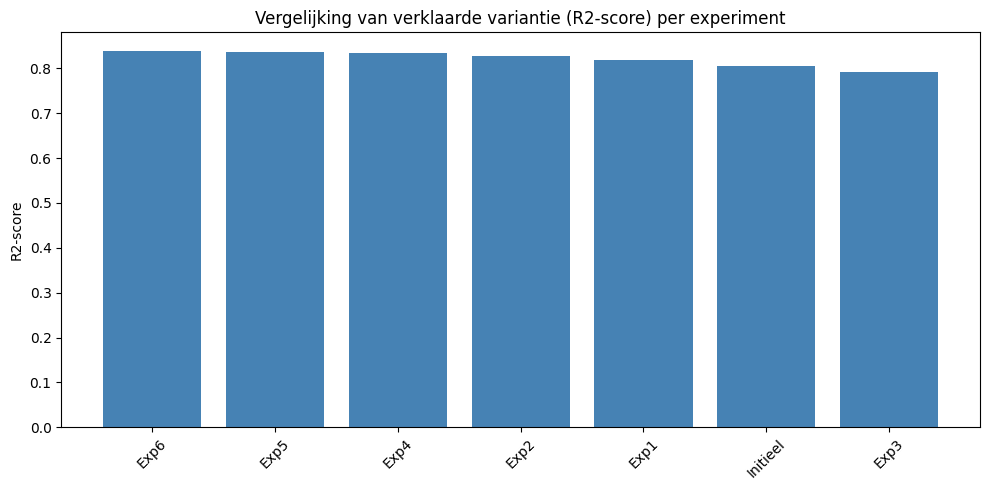

In [162]:
# 1. Sorteer de data aflopend op R2-score voor een logische, aflopende grafiek
plot_df = results_df.sort_values("R2", ascending=False)

# 2. Initialiseer de plot met overzichtelijke dimensies
plt.figure(figsize=(10, 5))

# 3. Bouw het staafdiagram op (X-as: Experiment Run, Y-as: R2-score)
plt.bar(plot_df["Run"], plot_df["R2"], color='steelblue')

# 4. Configureer de labels en de titel voor academische duidelijkheid
plt.ylabel("R2-score")
plt.title("Vergelijking van verklaarde variantie (R2-score) per experiment")

# 5. Roteer de labels op de X-as met 45 graden om overlappende tekst te voorkomen
plt.xticks(rotation=45)

# 6. Optimaliseer de witruimte en render de plot
plt.tight_layout()
plt.show()

### 12. Isolatie van het Optimale Model

Om het uiteindelijke model te selecteren voor verdere analyse, extraheren we programmatisch de configuratie met de hoogste predictieve waarde (de maximale $R^2$-score).

Door deze best presterende *run* te isoleren uit onze opgeslagen experimenten (`all_runs`), kunnen we de exacte hyperparameters en prestatie-indicatoren vastleggen. Dit model zal vervolgens dienen als ons definitieve regressiemodel.

In [163]:
# 1. Identificeer automatisch de rij met de hoogste R2-score in de resultaten
best_row = results_df.loc[results_df["R2"].idxmax()]
best_run_name = best_row["Run"]

# 2. Haal het bijbehorende, getrainde model (de volledige pipeline) op uit de dictionary
best_result = all_runs[best_run_name]

# 3. Presenteer de naam van de winnende configuratie
print(f"Beste experimentele run geëxtraheerd: {best_run_name}\n")

# 4. Selecteer alleen de relevante numerieke kolommen en rond ze netjes af
numeric_cols = ["Aantal features", "max_iter", "eta0", "RMSE", "MAE", "R2"]
print("Specificaties en finale prestatiemetrieken:")
print(best_row[numeric_cols].astype(float).round(4))

Beste experimentele run geëxtraheerd: Exp6

Specificaties en finale prestatiemetrieken:
Aantal features       10.0000
max_iter             200.0000
eta0                   0.0100
RMSE               35213.6482
MAE                21385.5200
R2                     0.8386
Name: 6, dtype: float64


### 13. Visuele Evaluatie van het Optimale Model (Scatterplot)

Om de voorspellende nauwkeurigheid van ons best presterende model visueel te valideren, construeren we een *scatterplot* die de werkelijke verkoopprijzen ($y$) uitzet tegen de voorspelde verkoopprijzen ($\hat{y}$).

Daarnaast voegen we een diagonale referentielijn toe ($y = \hat{y}$). Datapunten die exact op deze lijn vallen, representeren een perfecte voorspelling. De spreiding van de waarnemingen rondom deze as geeft direct inzicht in de variantie van de voorspellingsfouten (residuen) en helpt ons te identificeren of het model bijvoorbeeld moeite heeft met het voorspellen van uitzonderlijk dure huizen (*outliers*).

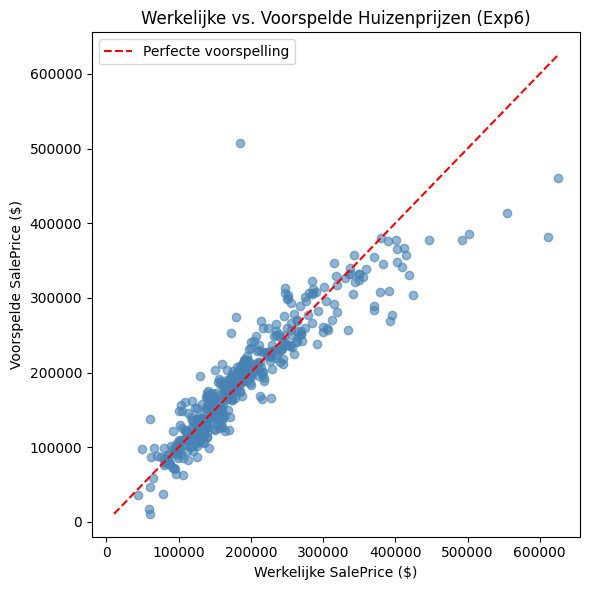

In [164]:
# 1. Extraheer de werkelijke testwaarden en de voorspellingen van het beste model
y_test_best = best_result["y_test"]
pred_best = best_result["predictions"]

# 2. Initialiseer een vierkante plot voor een symmetrische verhouding tussen de assen
plt.figure(figsize=(6, 6))

# 3. Plot de datapunten (gebruik alpha=0.6 om de dichtheid van overlappende punten weer te geven)
plt.scatter(y_test_best, pred_best, alpha=0.6, color='steelblue')

# 4. Bepaal de dynamische limieten voor de diagonale referentielijn
min_val = min(y_test_best.min(), pred_best.min())
max_val = max(y_test_best.max(), pred_best.max())

# 5. Teken de referentielijn voor 'perfecte voorspellingen' (y = x)
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfecte voorspelling')

# 6. Configureer de labels, titel en legenda
plt.xlabel("Werkelijke SalePrice ($)")
plt.ylabel("Voorspelde SalePrice ($)")
plt.title(f"Werkelijke vs. Voorspelde Huizenprijzen ({best_run_name})")
plt.legend()

# 7. Render de plot zonder overlappende elementen
plt.tight_layout()
plt.show()

### 14. Conclusie en Modeloptimalisatie

Op basis van de iteratieve experimenten kunnen we de volgende conclusies trekken over de modelontwikkeling:

* **Baseline vs. Feature Engineering:** De initiële *baseline* met drie features toonde een solide voorspellende waarde. Iteratieve toevoeging van domeinspecifieke variabelen (*House Style*, *Total Bsmt SF* en *Garage*) leidde aanvankelijk tot een significante prestatieverbetering.
* **Modeldegradatie:** De introductie van alle tien geselecteerde features resulteerde onverwachts in slechtere prestaties. Dit wijst op suboptimale convergentie van de *Stochastic Gradient Descent* optimizer wanneer de complexiteit toeneemt bij een statische leersnelheid.
* **Hyperparameter Tuning:** Door de leersnelheid te dynamiseren (*adaptive*) en het aantal iteraties (*epochs*) te verhogen, kon het model de complexere feature-ruimte effectief verwerken zonder te divergeren.

**Definitief Model (Exp6)**
De optimale configuratie combineert maximale informatievoorziening met een afgestemde optimizer:
* **Features:** 10 onafhankelijke variabelen (Categorisch: *Neighborhood*, *House Style*, *Garage*).
* **Hyperparameters:** `max_iter = 200`, `eta0 = 0.01`, `learning_rate = "adaptive"`, `penalty = "l2"`.

**Eindresultaat:** Deze configuratie maximaliseert de verklaarde variantie ($R^2$) en minimaliseert de voorspellingsfouten (RMSE en MAE) aanzienlijk ten opzichte van de initiële nulmeting. Hiermee is een robuust en geoptimaliseerd lineair regressiemodel gerealiseerd voor de Ames Housing dataset.